# Stacking

This notebook demonstrates how to perform image stacking using the EZPhot package. Image stacking is a fundamental technique in astronomical image processing that combines multiple exposures to improve signal-to-noise ratio and reduce noise.

## 1. Load Data

- Use the `DataBrowser` class to query and filter images
- Load science images for processing

> **💡 Optional Tip**: The `SDTDataQuerier` class provides methods to sync data from a central database to your local workspace, making it easy to work with large astronomical datasets.

### 🔍 1.1. Sync the data with SDTDataQuerier (Optional)


In [1]:
# If you connected the database, you can easily sync the data from the database. 
from ezphot.utils import SDTDataQuerier
sdtquery = SDTDataQuerier()
sdtquery.help()
target_name = 'T00528'

Help for SDTDataQuerier


Public methods:
- show_obsdestdata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obsdestfolder(folder_key: str = '*')
- show_obssourcedata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obssourcefolder(folder_key: str = '*')
- show_scidestdata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', pattern: str = '*.fits')
- show_scisourcedata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', file_pattern: str = '*.fits')
- show_scisourcefolder(folder_key: str = '*')
- sync_obsdata(foldername: str, file_pattern: str = '*.fits', ignore_exists: bool = True)
- sync_scidata(targetname: str, file_pattern: str = '*.fits', ignore_exists: bool = True)


In [2]:
# sync_scidata method will run multiple rsync between Science Source directory and destination directory.
print('Source directory:', sdtquery.helper.config['SDTDATA_SCISOURCEDIR'])
print('Target directory:', sdtquery.helper.config['SDTDATA_SCIDESTDIR'])
sdtquery.sync_scidata(
    targetname = target_name,
    file_pattern = '*.fits',
    ignore_exists = True
)

Source directory: /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750
Target directory: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1
Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:           rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750/T00528/7DT15/ /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT15/ rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/processed_1x1_gain2750/T00528/7DT14/ /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *.fits --exclude * /home/hhchoi1022/ezphot/data/connecte

**🔄 Sync Progress**: The rsync process copies FITS files from the source directory to your local destination directory.


### 🔍 1.2. Query Data with DataBrowser

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


In [3]:
# Then, you can query your data with DataBrowser class. 
# Since the data is copied to your private directory (['SCIDATA_SCIDESTDIR'](e.g. ~/ezphot/data/scidata by default) in configuration), you can use it as your own data. 
# You can also use it as a context for ezphot. 

from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
# You can query the data with the below keys.
for key, value in dbrowser.keys.items():
    print(key, value)


observatory {'7DT'}
telkey {'7DT_C361K_HIGH_1x1'}
objname {'T22924', 'T11109', 'T03051', 'T11704', 'T11622', 'T01505', 'T09370', 'T00465', 'T07169', 'T00595', 'T02072', 'T13257', 'T06269', 'T11898', 'T03768', 'T13707', 'T07128', 'T13722', 'T24735', 'T05004', 'T03198', 'T00464', 'T13560', 'T14354', 'T00405', 'T13558', 'T17321', 'T06467', 'T10452', 'T03073', 'T12025', 'T21733', 'T11148', 'T00486', 'T00596', 'T00529', 'T14574', 'T00527', 'T00915', 'T02535', 'T21343', 'T24804', 'T24225', 'T08643', 'T13823', 'T21742', 'T00409', 'T02874', 'T02349', 'T01501', 'T13520', 'T05634', 'T01161', 'T19684', 'T14918', 'T04237', 'T03458', 'T08297', 'T01428', 'T15696', 'T23736', 'T02452', 'T25303', 'T03263', 'T00463', 'T01701', 'T25337', 'T05376', 'T23142', 'T24558', 'T12053', 'T03364', 'T12165', 'T20716', 'T02595', 'T24028', 'T14943', 'T03377', 'T13824', 'T11971', 'T00528', 'T05281', 'T11573', 'T22614', 'T23488', 'T10856', 'T00311', 'T01933', 'T13557', 'T23968', 'T04803', 'T14479', 'T01631', 'T10413', '

Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Telescope**: 7DT16  
- **Filter**: r-band
- **Pattern**: Files ending with `*100.fits`


In [4]:
dbrowser.objname = target_name
dbrowser.telname = '7DT16'
dbrowser.filter = 'r'
dbrowser.search('*100.fits', return_type = 'path')

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


['/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250907_000520_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074905_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001416_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074535_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250820_032116_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_000705_r_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_001035_r_100.fits',


In [5]:
# If you wish to get the ScienceImage object, 
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images
# If you wish to get the metadata table from the keys, 
metadata_table = dbrowser.search('*100.fits', return_type = 'imginfo')

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:01<00:00, 82.18it/s] 


[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'
Loaded 90 FITS files from /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
Total FITS files combined: 90


In [6]:
metadata_table

file,altitude,azimuth,ccd-temp,gain,filter,imgtype,exptime,obsdate,locdate,jd,mjd,binning,object,objctid,obsmode,specmode,note,telescop
str120,str32,str32,str32,str21,str1,str5,str32,str23,str23,str32,str32,str21,str6,str32,str4,str7,str9,str5
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,37.80566,167.202362,-10.0,2750,r,LIGHT,100.0,2025-09-05T00:04:08.000,2025-09-04 20:04:08.000,2460923.50287037,60923.00287037037,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250907_000520_r_100.fits,38.233435,167.543446,-9.9,2750,r,LIGHT,100.0,2025-09-07T00:05:20.000,2025-09-06 20:05:20.000,2460925.5037037036,60925.003703703704,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074905_r_100.fits,35.847003,193.97872,-10.2,2750,r,LIGHT,100.0,2025-09-02T07:49:05.000,2025-09-02 03:49:05.000,2460920.8257523146,60920.32575231481,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001416_r_100.fits,37.536132,167.00423,-10.1,2750,r,LIGHT,100.0,2025-09-01T00:14:16.000,2025-08-31 20:14:16.000,2460919.509907407,60919.00990740741,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250902_074535_r_100.fits,36.029225,193.892131,-9.9,2750,r,LIGHT,100.0,2025-09-02T07:45:35.000,2025-09-02 03:45:35.000,2460920.8233217592,60920.32332175926,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250820_032116_r_100.fits,42.588008,174.57094,-10.1,2750,r,LIGHT,100.0,2025-08-20T03:21:16.000,2025-08-19 23:21:16.000,2460907.6397685185,60907.13976851852,1,T00528,58b4f2a07b0246b7b9d68efb4021c28f,Spec,specall,None,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_000705_r_100.fits,37.758685,167.166926,-9.9,2750,r,LIGHT,100.0,2025-09-04T00:07:05.000,2025-09-03 20:07:05.000,2460922.5049189813,60922.00491898148,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250904_001035_r_100.fits,37.925522,167.294357,-9.9,2750,r,LIGHT,100.0,2025-09-04T00:10:35.000,2025-09-03 20:10:35.000,2460922.507349537,60922.00734953704,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250901_001601_r_100.fits,37.621042,167.065116,-10.2,2750,r,LIGHT,100.0,2025-09-01T00:16:01.000,2025-08-31 20:16:01.000,2460919.5111226854,60919.01112268519,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT16


## 2. Check Your Images

Now that we have loaded our data, let's inspect the images to understand their properties and quality:

> **Memory Warning**: Astronomical images can be large. Always use `ScienceImage.clear()` to free memory when you're done with an image.

(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT16_T00528_20250905_000408_r_100.fits'}>)

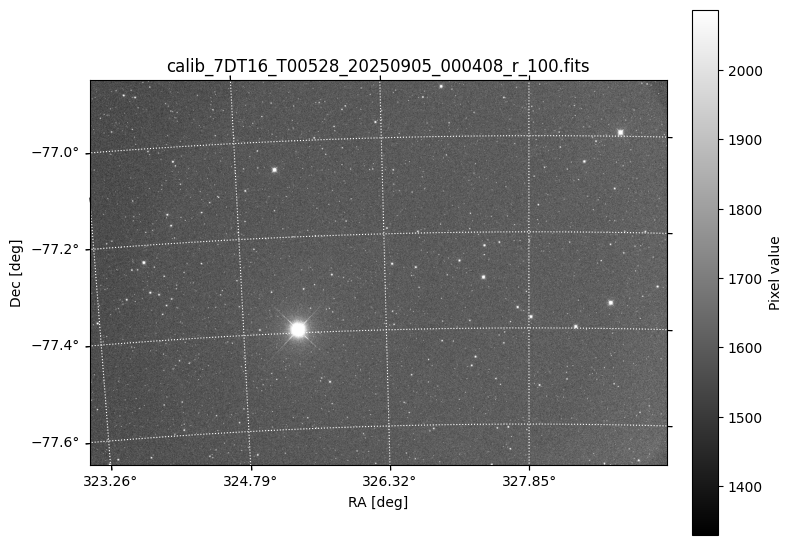

In [7]:
target_img = target_imglist[0]
target_img.show('coord')

In [8]:
# [CAUTION] For memory management, NOTE the below example.
# When you run any functions that load the data, all data are stored in the memory (data_load = True).
target_img

ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = True,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = r,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
)

Use `ScienceImage.clear()` to free memory when you're done with an image:

In [9]:
#To clear the memory, run ScienceImage.clear()
target_img.clear()
target_img

Cleared data and/or header from memory.


ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = r,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
)

In [10]:
# You can check the image with ds9 if X11 forward is available (via SSH)
target_img.run_ds9()

Running "ds9 -scalemode zscale -scale lock yes -frame lock image /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits &" in the terminal...


bash: cannot set terminal process group (2263633): Inappropriate ioctl for device
bash: no job control in this shell


## 3. Background Estimation

Background estimation is crucial for accurate photometry and image analysis. Here we are going to repeat the procedure in :doc:`example/backgroundestimation`.

- **Estimate background** using the SEP (Source Extractor Python) algorithm
- **Apply source masking** to improve background estimation

> **Science Note**: Background estimation removes sky brightness and instrumental effects, revealing the true astronomical sources in your images.

### 3.1. Background estimation


[1] 2657074
application-specific initialization failed: no display name and no $DISPLAY environment variable
Unable to initialize window system.


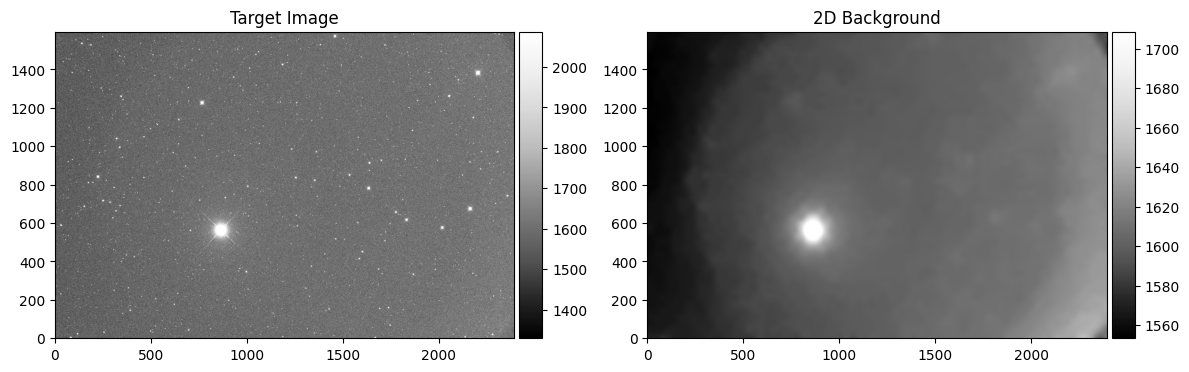

Cleared data and header from memory.


In [11]:
# Calculate the background map
target_bkg = target_img.calculate_bkg(
    target_srcmask = None,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 128,
    filter_size = 3,
    save = False,
    verbose = True,
    visualize = True
)
# Clear the memory
target_bkg.clear(verbose = True)

### 3.2. Advanced Background Estimation

Sometimes the background model may include real sources like saturated stars or extended objects. In such cases, you can apply source masks to improve the background estimation.

> **💡 Pro Tip**: Source masking helps create cleaner background models by excluding bright objects that could bias the background calculation.


#### 3.2.1. Automatic Source Mask Generation 

Masking source... [sigma = 5.0, mask_radius_factor = 2]
5675 non-saturated, 105 saturated sources
5780 sources masked.


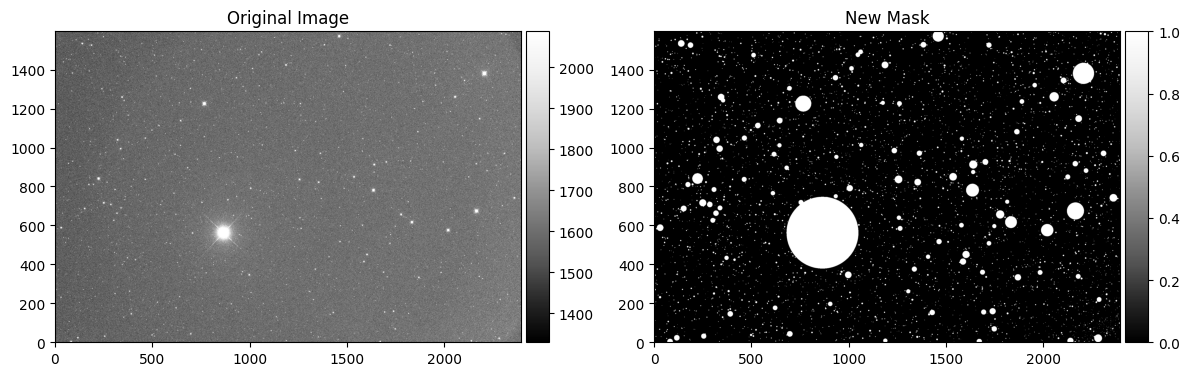

In [12]:
target_srcmask = target_img.calculate_sourcemask(
    sigma = 5.0,
    mask_radius_factor = 2,
    saturation_level = 50000,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False
)

#### 3.2.2. Re-generation of Background Map with Source Mask


External mask is loaded.


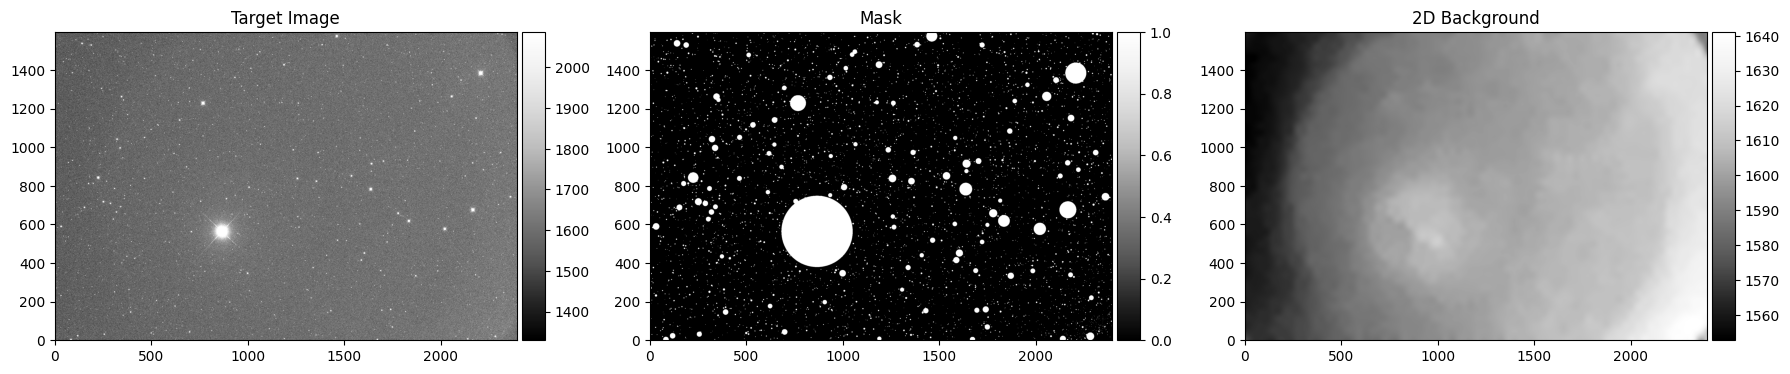

In [13]:
target_bkg_with_srcmask = target_img.calculate_bkg(
    target_srcmask = target_srcmask,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 128,
    filter_size = 3,
)

In [14]:
# Write and clear the memory
target_srcmask.write()
target_bkg_with_srcmask.write()
target_srcmask.clear()
target_bkg_with_srcmask.clear()

# After writing the files, you can access to the files as attributes of the ScienceImage object.
print(target_img.bkgmap)
print(target_img.sourcemask)

Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits.srcmask
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits.bkgmap
Cleared data and header from memory.
Cleared data and header from memory.
Background(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits.bkgmap,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r
)
Mask(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT16/r/calib_7DT16_T00528_20250905_000408_r_100.fits.srcmask,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1

In [15]:
# Run for all target_imglist with multiprocessing
from multiprocessing import Pool
from tqdm import tqdm

def calculate_bkg(target_img):    
    target_srcmask = target_img.calculate_sourcemask(   
        sigma = 5.0,
        mask_radius_factor = 2,
        saturation_level = 50000,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )
    target_img.calculate_bkg(
        target_srcmask = target_srcmask,
        target_ivpmask = None,
        is_2D_bkg = True,
        box_size = 128,
        filter_size = 3,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )    
                
    target_srcmask.clear(verbose = False)
    target_bkg.clear(verbose = False)
    
with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    list(tqdm(pool.imap(calculate_bkg, target_imglist), 
              total=len(target_imglist), 
              desc="Calculating backgrounds"))


Calculating backgrounds: 100%|██████████| 90/90 [04:14<00:00,  2.83s/it]


## 4. Image stacking

Image stacking is possible with Stack class in ezphot. There are multiple options available before stacking

- **Background subtraction** (when target_bkglist is not None)
- **Zeropoint scaling** to match the level of flux between multiple images (when scale == True, ZP_key must exist in the header. To update ZP information, run photometriccalibration before this process)
- **Image convolution** to match the PSF size of multiple images (when convolve == True, seeing_key must exist in the header. To update SEEING information, run photometriccalibration before this process)

> **Science Note**: You can also stack Background RMS map by target_bkgrmslist parameters. 

## 4.1. Image stacking

In [16]:
from ezphot.methods import Stack

stacker = Stack()
stacker.help()

Help for Stack


Public methods:
- match_seeing(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, target_bkglist: Optional[List[ezphot.imageobjects.background.Background]] = None, seeing_key: str = 'SEEING', kernel: str = 'gaussian', save: bool = False, overwrite: bool = False, visualize: bool = True, verbose: bool = True, **kwargs)
- match_zeropoints(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, method: str = 'median', zp_key: str = 'ZP_APER_1', save: bool = False, overwrite: bool = False, verbose: bool = True, n_proc: int = 8, **kwargs)
- select_quality_images(target_imglist: Union[List[ezphot.imageobjects.scienceimage.ScienceImage], List[ezphot.imageobjects

In [17]:
target_imglist = target_imgset.target_images
target_bkglist = target_imgset.bkgmap
stacked_img, _ = stacker.stack_multiprocess(
    target_imglist = target_imglist,
    target_bkglist = target_bkglist,
    n_proc = 16,
    scale = False,
    convolve = False,
    save = True,
    verbose = False,
)

Performing image reprojection...: 100%|██████████████████████████| 90/90 [02:16]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'calib_7DT16_T00528_20250905_000408_r_100.com.fits'}, xlabel='X pixel', ylabel='Y pixel'>)

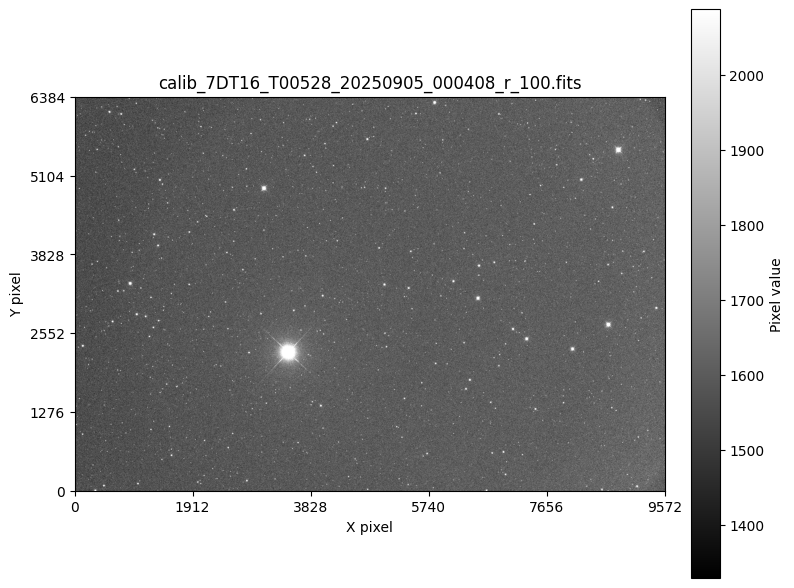

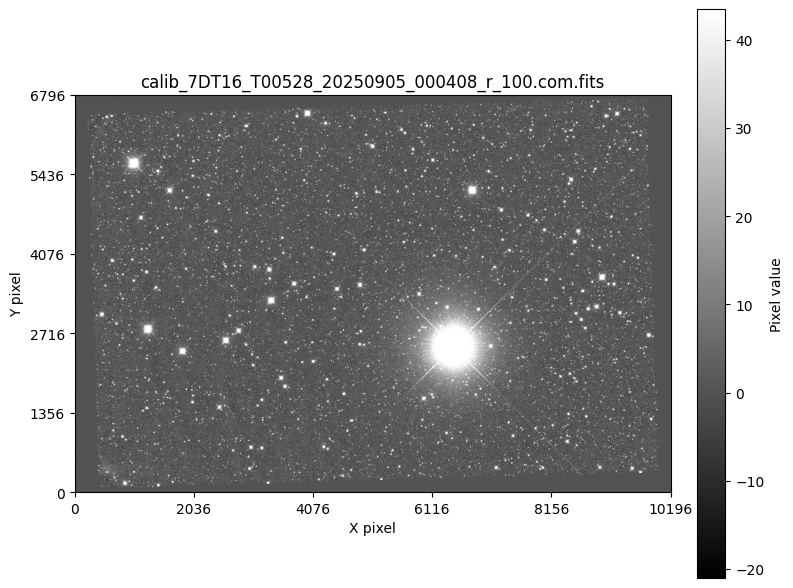

In [19]:
target_img.show()
stacked_img.show()

## 4.2. Image and Background RMS stacking 

In [ ]:
from multiprocessing import Pool
from tqdm import tqdm
from ezphot.methods import Preprocess
from ezphot.imageobjects import CalibrationImage
preprocessor = Preprocess()
def calculate_bkgrms(target_img):
    mbias_tbl = preprocessor.get_masterframe_from_image(target_img, 'BIAS', 60)
    mdark_tbl = preprocessor.get_masterframe_from_image(target_img, 'DARK', 60)
    mflat_tbl = preprocessor.get_masterframe_from_image(target_img, 'FLAT', 60)
    mbias = CalibrationImage(mbias_tbl[0]['file'])
    mdark = CalibrationImage(mdark_tbl[0]['file'])
    mflat = CalibrationImage(mflat_tbl[0]['file'])
    target_bkgrms = target_img.calculate_bkgrms_from_propagation(
        target_bkg = target_img.bkgmap,
        mbias = mbias,
        mdark = mdark,
        mflat = mflat,
        mflaterr = None,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )
    target_bkgrms.clear(verbose = False)
    mbias.clear(verbose = False)
    mdark.clear(verbose = False)
    mflat.clear(verbose = False)

with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    target_bkgrmslist = list(tqdm(pool.imap(calculate_bkgrms, target_imglist), 
                                  total=len(target_imglist), 
                                  desc="Calculating background RMS"))

Calculating background RMS: 100%|██████████| 90/90 [02:48<00:00,  1.87s/it]


In [ ]:
from ezphot.methods import Stack

stacker = Stack()
stacker.help()

In [11]:
target_imglist = target_imgset.target_images
target_bkglist = target_imgset.bkgmap
target_bkgrmslist = target_imgset.bkgrms
stacked_img, _ = stacker.stack_multiprocess(
    target_imglist = target_imglist,
    target_bkglist = target_bkglist,
    target_bkgrmslist = target_bkgrmslist,
    n_proc = 16,
    scale = False,
    convolve = False,
    save = True,
    verbose = False,
)

Help for Stack


Public methods:
- match_seeing(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, target_bkglist: Optional[List[ezphot.imageobjects.background.Background]] = None, seeing_key: str = 'SEEING', kernel: str = 'gaussian', save: bool = False, overwrite: bool = False, visualize: bool = True, verbose: bool = True, **kwargs)
- match_zeropoints(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, method: str = 'median', zp_key: str = 'ZP_APER_1', save: bool = False, overwrite: bool = False, verbose: bool = True, n_proc: int = 8, **kwargs)
- select_quality_images(target_imglist: Union[List[ezphot.imageobjects.scienceimage.ScienceImage], List[ezphot.imageobjects

Subtracting background...:  21%|██████▉                          | 19/90 [02:06][1] 2670878
application-specific initialization failed: no display name and no $DISPLAY environment variable
Unable to initialize window system.
Performing image/bkgrms reprojection...: 100%|███████████████████| 90/90 [08:09]


## 4.3. Image stacking with convolution or ZP scaling 
To do this, please refer Example "photometriccalibration". 
You can apply FWHM matching and ZP matching after running photometriccalibration process. 